# E-Commerce Customer Analysis

## Exploratory Data Analysis (EDA)

This project analyzes an e-commerce customer orders dataset to understand
customer behavior, product categories, sales patterns, and data quality.

### Objectives
- Understand the structure of the dataset
- Analyze customer and product information
- Identify sales trends and patterns
- Find possible anomalies and data-quality issues
- Generate useful insights using statistics and visualization

In [ ]:
## Analytical Questions

1. Which product category has the highest sales?
2. Which city has the highest number of orders?
3. Which age group has the most customers?
4. Is there a relationship between product price and quantity?
5. How do customer ratings vary across categories?
6. Which month has the highest sales?
7. Are there missing values, duplicates, or unusual values in the dataset?

In [1]:
df = pd.read_csv("dataset/ecommerce_customer_analysis_clean.csv")
df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("dataset/ecommerce_customer_analysis_clean.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/ecommerce_customer_analysis_clean.csv'

In [4]:
df = pd.read_csv("ecommerce_customer_analysis_clean.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_customer_analysis_clean.csv'

In [5]:
df = pd.read_csv("ecommerce_customer_analysis_clean.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ecommerce_customer_analysis_clean.csv'

In [6]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\pc\Desktop\E-commerce EDA
['Data set', 'E-Commerce_Customer_Analysis.ipynb']


In [ ]:
import pandas as pd
import os

matches = []

for root, dirs, files in os.walk(os.path.expanduser("~")):
    for file in files:
        if file.lower().endswith(".csv") and "ecommerce" in file.lower():
            matches.append(os.path.join(root, file))

print(matches)import pandas as pd


['C:\\Users\\pc\\Downloads\\ecommerce_customer_analysis_clean.csv']


In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\pc\Downloads\ecommerce_customer_analysis_clean.csv")
df.head()

,Order_ID,Customer_Age,Gender,City,Product_Category,Product_Price,Quantity,Rating,Order_Date
0,ORD1001,40,Male,Pune,Electronics,32770.59,4,4.1,2025-09-10
1,ORD1002,29,Female,Hyderabad,Books,1748.23,4,3.0,2025-07-14
2,ORD1003,27,Female,Kolkata,Beauty,1897.50,5,4.7,2025-12-30
3,ORD1004,31,Female,Hyderabad,Home & Kitchen,3274.94,5,4.5,2025-10-08
4,ORD1005,43,Male,Hyderabad,Home & Kitchen,3145.28,4,3.4,2025-01-07


In [9]:
df .shape

(500, 9)

In [10]:
df .info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          500 non-null    str    
 1   Customer_Age      500 non-null    int64  
 2   Gender            500 non-null    str    
 3   City              495 non-null    str    
 4   Product_Category  500 non-null    str    
 5   Product_Price     500 non-null    float64
 6   Quantity          500 non-null    int64  
 7   Rating            492 non-null    float64
 8   Order_Date        500 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 35.3 KB


In [11]:
df .dtypes

Order_ID                str
Customer_Age          int64
Gender                  str
City                    str
Product_Category        str
Product_Price       float64
Quantity              int64
Rating              float64
Order_Date              str
dtype: object

In [12]:
df .isnull().sum()

Order_ID            0
Customer_Age        0
Gender              0
City                5
Product_Category    0
Product_Price       0
Quantity            0
Rating              8
Order_Date          0
dtype: int64

In [13]:
df .duplicated().sum()

np.int64(0)

In [14]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df.dtypes

Order_ID                       str
Customer_Age                 int64
Gender                         str
City                           str
Product_Category               str
Product_Price              float64
Quantity                     int64
Rating                     float64
Order_Date          datetime64[us]
dtype: object

In [15]:
df["Total_Sales"] = df["Product_Price"] * df["Quantity"]
df.head()

,Order_ID,Customer_Age,Gender,City,Product_Category,Product_Price,Quantity,Rating,Order_Date,Total_Sales
0,ORD1001,40,Male,Pune,Electronics,32770.59,4,4.1,2025-09-10,131082.36
1,ORD1002,29,Female,Hyderabad,Books,1748.23,4,3.0,2025-07-14,6992.92
2,ORD1003,27,Female,Kolkata,Beauty,1897.50,5,4.7,2025-12-30,9487.50
3,ORD1004,31,Female,Hyderabad,Home & Kitchen,3274.94,5,4.5,2025-10-08,16374.70
4,ORD1005,43,Male,Hyderabad,Home & Kitchen,3145.28,4,3.4,2025-01-07,12581.12


In [16]:
df .describe()

,Customer_Age,Product_Price,Quantity,Rating,Order_Date,Total_Sales
count,500.000000,500.000000,500.00000,492.000000,500,500.000000
mean,38.360000,7417.589660,3.00800,3.716463,2025-07-01 01:52:19.200000,22991.214280
min,18.000000,110.320000,1.00000,2.500000,2025-01-01 00:00:00,177.800000
25%,27.000000,1312.030000,2.00000,3.100000,2025-03-23 12:00:00,3429.945000
50%,38.000000,2860.595000,3.00000,3.700000,2025-07-08 12:00:00,7613.640000
75%,49.000000,6847.650000,4.00000,4.400000,2025-10-03 00:00:00,20784.790000
max,60.000000,49937.800000,5.00000,5.000000,2025-12-30 00:00:00,249689.000000
std,12.596815,11160.558862,1.38556,0.729725,NaN,40756.143938


In [17]:
category_sales = df.groupby("Product_Category")["Total_Sales"].sum().sort_values(ascending=False)
category_sales

Product_Category
Electronics       7618533.31
Home & Kitchen    1572338.89
Sports            1035861.69
Clothing           534171.04
Beauty             444479.75
Books              290222.46
Name: Total_Sales, dtype: float64

NameError: name 'plt' is not defined

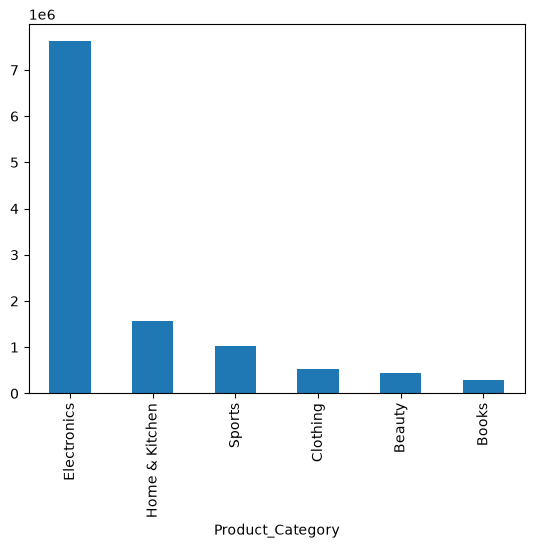

In [18]:
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [19]:
city_orders = df["City"].value_counts()

city_orders

City
Ahmedabad    74
Delhi        70
Bengaluru    66
Kolkata      65
Chennai      65
Hyderabad    59
Pune         48
Mumbai       48
Name: count, dtype: int64

In [20]:
age_groups = pd.cut(
    df["Customer_Age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=["<18", "18-25", "26-35", "36-45", "46-60", "60+"]
)

age_groups.value_counts().sort_index()

Customer_Age
<18       15
18-25     91
26-35    120
36-45    109
46-60    165
60+        0
Name: count, dtype: int64

In [21]:
df["Product_Price"].corr(df["Quantity"])

np.float64(0.04400428302679178)

In [22]:
df.groupby("Product_Category")["Rating"].mean().sort_values(ascending=False)

Product_Category
Clothing          3.779747
Beauty            3.751948
Home & Kitchen    3.744186
Books             3.709890
Sports            3.674648
Electronics       3.642045
Name: Rating, dtype: float64

In [23]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"].sum()
monthly_sales

Order_Date
2025-01    1147547.15
2025-02    1276458.89
2025-03     677980.05
2025-04    1045581.99
2025-05     544475.63
2025-06     729565.25
2025-07     671426.74
2025-08     851239.67
2025-09    1126727.56
2025-10    1013497.54
2025-11     717702.08
2025-12    1693404.59
Freq: M, Name: Total_Sales, dtype: float64

In [24]:
monthly_sales.idxmax(),
monthly_sales.max()

np.float64(1693404.59)

In [25]:
### Key Findings

- Electronics generated the highest total sales of 7,618,593.31.
- Ahmedabad had the highest number of orders with 74 orders.
- The 46–60 age group had the highest number of orders with 165 orders.
- The correlation between Product Price and Quantity was 0.044, showing a very weak relationship.
- December 2025 recorded the highest monthly sales of 1,693,404.59.
- Missing values were found in City (5) and Rating (8).
- Category-wise average customer ratings were also analyzed to compare customer satisfaction across product categories.

SyntaxError: invalid character '–' (U+2013) (975554191.py, line 5)

In [26]:
## Trends, Patterns and Data Issues

### Trends and Patterns
- Electronics was the strongest sales-generating product category.
- Ahmedabad recorded the highest number of orders among the cities.
- Customers aged 46-60 formed the largest age group.
- Product price and quantity showed almost no linear relationship.
- December 2025 had the highest monthly sales.

### Data Issues
- The dataset contains 5 missing values in the City column.
- The Rating column contains 8 missing values.
- Order_Date was converted to a date format for monthly analysis.
- Total_Sales was calculated using Product_Price * Quantity.

SyntaxError: invalid syntax (3330836589.py, line 4)

In [27]:
## Trends, Patterns and Data Issues

### Trends and Patterns
- Electronics was the strongest sales-generating product category.
- Ahmedabad recorded the highest number of orders among the cities.
- Customers aged 46-60 formed the largest age group.
- Product price and quantity showed almost no linear relationship.
- December 2025 had the highest monthly sales.

### Data Issues
- The dataset contains 5 missing values in the City column.
- The Rating column contains 8 missing values.
- Order_Date was converted to a date format for monthly analysis.
- Total_Sales was calculated using Product_Price * Quantity.

SyntaxError: invalid syntax (3330836589.py, line 4)

In [28]:
## Trends, Patterns and Data Issues

### Trends and Patterns
- Electronics was the strongest sales-generating product category.
- Ahmedabad recorded the highest number of orders among the cities.
- Customers aged 46-60 formed the largest age group.
- Product price and quantity showed almost no linear relationship.
- December 2025 had the highest monthly sales.

### Data Issues
- The dataset contains 5 missing values in the City column.
- The Rating column contains 8 missing values.
- Order_Date was converted to a date format for monthly analysis.
- Total_Sales was calculated using Product_Price * Quantity.

SyntaxError: invalid syntax (3330836589.py, line 4)

## Conclusion

This exploratory data analysis examined customer orders, product categories, prices, quantities, ratings, cities, and sales trends.

The analysis found that Electronics generated the highest sales, Ahmedabad had the highest number of orders, and the 46-60 age group had the most orders. The relationship between product price and quantity was very weak. December 2025 recorded the highest monthly sales.

Overall, the EDA helped identify important sales patterns, customer characteristics, and data quality issues in the e-commerce dataset.